### RAG-Fusion

#### 一、核心逻辑
与多查询检索相似：用户的问题可能是因为措辞不当或语义模糊，导致无法在向量看空间中直接匹配到最相关的文档。工作流程可以分为四个阶段：
- 多查询生成：利用LLM针对用户的原始输入，从不同角度生成多个相关的搜索查询
- 独立检索：对每一个生成的查询分别执行独立的检索。产生一个列表的列表，每个子列表中都包含该特定查询找回的文档
- 倒数排名融合（Reciprocal Rank Fusion, RRF）：这是 RAG Fusion 的灵魂。它不是简单地取文档的并集，而是使用 RRF 算法对所有检索到的文档进行重新排名。该算法通过观察文档在多个检索列表中的排名位置，来计算一个综合得分，从而构建一个单一且整合的排名列表
- 最终生成：将RRF排序后的前几个最相关的文档作为上下文，传递给LLM生成最终答案

#### 二、RRF算法的直觉
RRF 的优势在于它能有效地整合来自不同检索路径的结果。如果一个文档在多个查询的检索结果中都排在靠前的位置，RRF 算法会赋予它极高的最终排名,。这种机制比简单的“去重并集”更精准，因为它考虑了不同搜索视角下文档的“共识相关性”

#### 三、工作流程
- 生成链：定义一个提示词模板，要求 LLM 输出多个查询，并将结果解析为一个字符串列表
- 检索逻辑：针对列表中的每个查询运行 retriever.get_relevant_documents()
- 重排函数：应用 reciprocal_rank_fusion 函数对找回的文档进行打分和排序，筛选出排名前 N 的精选文档

#### 四、应用场景
- 多向量库检索：当你需要同时在不同的向量数据库中搜索，并希望获得一个统一的推荐列表时。
- 复杂查询：对于需要从多维度信息汇总的问题，RAG Fusion 能够提取出那些在多个维度搜索中都表现优秀的“精品文档”。
- 提升可靠性：相比于基础 RAG，它通过多路搜索和数学重排，显著提高了检索的覆盖面和准确度

In [1]:
# Indexing
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
#Split
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever() 

C:\Users\23017\AppData\Local\Temp\ipykernel_36032\2382097115.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1249.79it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_36032\2382097115.py:15: LangChainDep

In [4]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.chat_models.tongyi import ChatTongyi  # 通义千问
from langchain_core.load import dumps, loads
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough
import os 
# 通义千问配置（使用你提供的API Key和模型）
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY

In [5]:
llm = ChatTongyi(
  model = LLM_MODEL,
  temperature = TEMPERATURE,
)

template = """你是一个实用的助手，会根据单一输入查询生成多个搜索关键词。
生成与以下内容相关的多个搜索查询：{question}
输出（4 个查询）："""

prompt_rag_fusion = PromptTemplate.from_template(template)

#构建多查询生成链
generate_queries = (
    prompt_rag_fusion 
    | llm 
    | StrOutputParser() 
    | (lambda x: [q.strip() for q in x.split("\n") if q.strip()])  # 清理空行和空格
)

In [10]:
question = "什么是LLM智能体的任务分解？"

def retrieval_chain_rag_fusion(results: list[list], k =60):

    """
    Reciprocal Rank Fusion（RRF）：融合多个排序后的文档列表，计算融合得分
    Args:
        results: 多个文档列表的集合（每个子列表是一组按相关性排序的文档）
        k: RRF公式中的调节参数（默认60，行业常用值）
    Returns:
        融合后按得分降序排列的文档+得分列表
    """
    # 修正：初始化为字典（key=文档字符串，value=融合得分）
    fused_scores = {}

    # 遍历每个排序后的文档列表
    for docs in results:
        # 遍历列表中的每个文档及其排名（rank从0开始，RRF公式中rank需+1）
        for rank, doc in enumerate(docs):
            doc_str = dumps(doc)
            # 初始化得分（如果文档未出现过）
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0.0
            # RRF核心公式：得分累加 1/(rank + k)（注意rank从0开始，需+1）
            previous_score = fused_scores[doc_str]
            fused_scores[doc_str] += 1.0 / (rank + 1 + k)

    # 按得分降序排序，还原文档对象并返回
    reranked_result = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    return reranked_result

In [11]:
template = """ 基于内容回答下列问题
{context}

Question: {question}
"""
prompt = PromptTemplate.from_template(template)

final_rag_chain = (
    {"context":retrieval_chain_rag_fusion,
     "question": itemgetter("question")}
     | prompt 
     | llm
     | StrOutputParser()
)
response = final_rag_chain.invoke({"question": question})
print(response)

C:\Users\23017\AppData\Local\Temp\ipykernel_36032\3491380091.py:30: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  (loads(doc), score)


LLM智能体的任务分解是指将一个复杂的任务拆解为一系列更小、更易处理的子任务的过程。这种分解有助于LLM更好地理解和执行任务，提高效率和准确性。通过任务分解，LLM可以逐步完成每个子任务，最终实现整体目标。


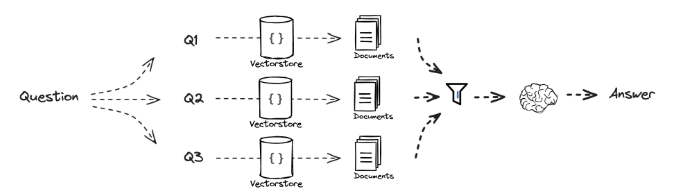